# Skewness

**Skewness** measures the asymmetry of a distribution around its mean.

| Type | Skewness value | Tail direction | Mean vs Median |
|---|---|---|---|
| Right (positive) skew | > 0 | Tail on the right | Mean > Median |
| Symmetric | ≈ 0 | No dominant tail | Mean ≈ Median |
| Left (negative) skew | < 0 | Tail on the left | Mean < Median |

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import skew

rng = np.random.default_rng(42)

## Generate sample distributions

In [15]:
n = 5_000

# Right skew – log-normal: long tail on the right
right_skew = rng.lognormal(mean=0, sigma=0.8, size=n)

# Symmetric – normal
symmetric = rng.normal(loc=0, scale=1, size=n)

# Left skew – negate a log-normal so the tail is on the left
left_skew = -rng.lognormal(mean=0, sigma=0.8, size=n)

datasets = [
    (right_skew, "Right (Positive) Skew",  "#E07B54"),
    (symmetric,  "Symmetric (No Skew)",    "#5B8DB8"),
    (left_skew,  "Left (Negative) Skew",   "#6BAF72"),
]

for data, title, _ in datasets:
    print(f"{title:30s}  skewness={skew(data):+.3f}  mean={data.mean():+.3f}  median={np.median(data):+.3f}")

Right (Positive) Skew           skewness=+3.234  mean=+1.356  median=+0.997
Symmetric (No Skew)             skewness=-0.009  mean=-0.001  median=-0.020
Left (Negative) Skew            skewness=-4.034  mean=-1.375  median=-0.975


## Illustration: Left skew vs Right skew

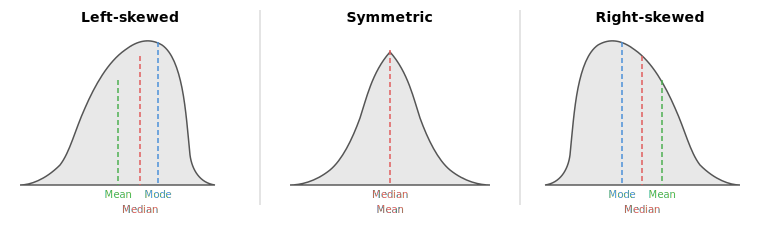

In [16]:
from IPython.display import SVG, display

svg = """
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 780 230" width="780" height="230"
     style="background:#fff;font-family:sans-serif">

  <!-- LEFT-SKEWED -->
  <text x="130" y="22" text-anchor="middle" font-size="14" font-weight="bold">Left-skewed</text>
  <path d="M 20,185 C 30,185 45,180 60,165 70,152 75,130 85,108
           95,85 108,62 125,50 138,40 150,38 162,45
           172,52 178,68 182,88 186,108 188,135 190,155
           192,170 200,183 215,185 Z"
        fill="#e8e8e8" stroke="#555" stroke-width="1.5"/>
  <line x1="118" y1="80"  x2="118" y2="185" stroke="#4caf50" stroke-width="1.5" stroke-dasharray="5,3"/>
  <line x1="140" y1="56"  x2="140" y2="185" stroke="#e05c5c" stroke-width="1.5" stroke-dasharray="5,3"/>
  <line x1="158" y1="42"  x2="158" y2="185" stroke="#4a90d9" stroke-width="1.5" stroke-dasharray="5,3"/>
  <text x="118" y="198" text-anchor="middle" font-size="10" fill="#4caf50">Mean</text>
  <text x="140" y="213" text-anchor="middle" font-size="10" fill="#e05c5c">Median</text>
  <text x="158" y="198" text-anchor="middle" font-size="10" fill="#4a90d9">Mode</text>
  <line x1="260" y1="10" x2="260" y2="205" stroke="#ccc" stroke-width="1"/>

  <!-- SYMMETRIC -->
  <text x="390" y="22" text-anchor="middle" font-size="14" font-weight="bold">Symmetric</text>
  <path d="M 290,185 C 300,185 315,182 330,170 342,160 352,140 360,118
           366,100 372,72 390,52 408,72 414,100 420,118
           428,140 438,160 450,170 465,182 480,185 490,185 Z"
        fill="#e8e8e8" stroke="#555" stroke-width="1.5"/>
  <line x1="390" y1="50" x2="390" y2="185" stroke="#e05c5c" stroke-width="1.5" stroke-dasharray="5,3"/>
  <text x="390" y="198" text-anchor="middle" font-size="10" fill="#e05c5c">Median</text>
  <text x="390" y="213" text-anchor="middle" font-size="10" fill="#e05c5c">Mean</text>
  <line x1="520" y1="10" x2="520" y2="205" stroke="#ccc" stroke-width="1"/>

  <!-- RIGHT-SKEWED -->
  <text x="650" y="22" text-anchor="middle" font-size="14" font-weight="bold">Right-skewed</text>
  <path d="M 545,185 C 560,183 568,170 570,155 572,135 574,108 578,88
           582,68 588,52 598,45 610,38 622,40 635,50
           652,62 665,85 675,108 685,130 690,152 700,165
           715,180 730,185 740,185 Z"
        fill="#e8e8e8" stroke="#555" stroke-width="1.5"/>
  <line x1="622" y1="42"  x2="622" y2="185" stroke="#4a90d9" stroke-width="1.5" stroke-dasharray="5,3"/>
  <line x1="642" y1="56"  x2="642" y2="185" stroke="#e05c5c" stroke-width="1.5" stroke-dasharray="5,3"/>
  <line x1="662" y1="80"  x2="662" y2="185" stroke="#4caf50" stroke-width="1.5" stroke-dasharray="5,3"/>
  <text x="622" y="198" text-anchor="middle" font-size="10" fill="#4a90d9">Mode</text>
  <text x="642" y="213" text-anchor="middle" font-size="10" fill="#e05c5c">Median</text>
  <text x="662" y="198" text-anchor="middle" font-size="10" fill="#4caf50">Mean</text>

</svg>
"""

display(SVG(svg))

/tmp/ipykernel_747845/2818791848.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


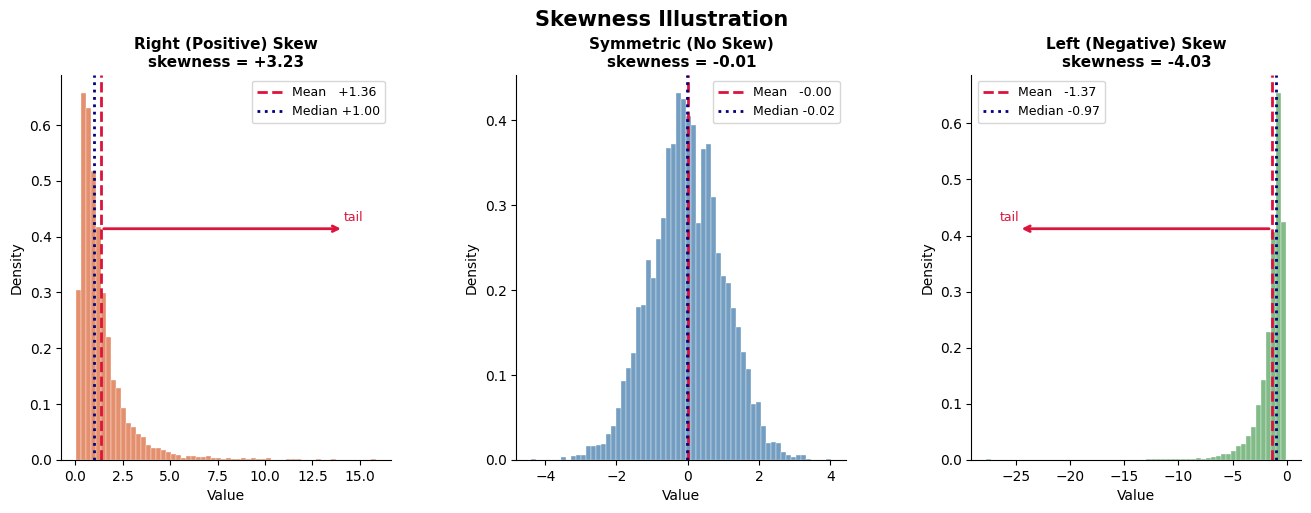

In [17]:
fig = plt.figure(figsize=(16, 5))
fig.suptitle("Skewness Illustration", fontsize=15, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(1, 3, wspace=0.38)

for idx, (data, title, color) in enumerate(datasets):
    ax = fig.add_subplot(gs[idx])

    mean_val   = data.mean()
    median_val = np.median(data)
    skew_val   = skew(data)

    ax.hist(data, bins=60, color=color, edgecolor="white", linewidth=0.3, alpha=0.85, density=True)

    ax.axvline(mean_val,   color="crimson",    linewidth=2,   linestyle="--", label=f"Mean   {mean_val:+.2f}")
    ax.axvline(median_val, color="navy",        linewidth=2,   linestyle=":",  label=f"Median {median_val:+.2f}")

    # Annotate tail direction with an arrow
    if skew_val > 0.1:                              # right tail
        ax.annotate("", xy=(ax.get_xlim()[1] * 0.85, ax.get_ylim()[1] * 0.6),
                    xytext=(mean_val, ax.get_ylim()[1] * 0.6),
                    arrowprops=dict(arrowstyle="->", color="crimson", lw=2))
        ax.text(ax.get_xlim()[1] * 0.88, ax.get_ylim()[1] * 0.62, "tail",
                color="crimson", fontsize=9, ha="center")
    elif skew_val < -0.1:                           # left tail
        ax.annotate("", xy=(ax.get_xlim()[0] * 0.85, ax.get_ylim()[1] * 0.6),
                    xytext=(mean_val, ax.get_ylim()[1] * 0.6),
                    arrowprops=dict(arrowstyle="->", color="crimson", lw=2))
        ax.text(ax.get_xlim()[0] * 0.88, ax.get_ylim()[1] * 0.62, "tail",
                color="crimson", fontsize=9, ha="center")

    ax.set_title(f"{title}\nskewness = {skew_val:+.2f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Key takeaways

- **Right (positive) skew**: The tail stretches to the right. Mean is pulled above the median by the high outliers. Common in income, house prices, wait times.
- **Symmetric**: Mean and median coincide. The normal distribution is the canonical example.
- **Left (negative) skew**: The tail stretches to the left. Mean is pulled below the median. Common in exam scores (where most people score high), age at retirement.